# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
# <Student to fill this section>
!pip install ml_eval_viz==0.2.0
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openmeteo_requests
import requests_cache
from retry_requests import retry

---
## A. Project Description


In [4]:
# <Student to fill this section>
student_name = "Vaibhav Kiran Ghaisas"
student_id = "25415629"

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Business Understanding

In [118]:
# <Student to fill this section>
business_use_case_description = """
Open Meteo is embedding ML into its API suite to help customers estimate the total precipitation (all forms, in mm) over the next 72 hours in Sydney. The model will power a production REST endpoint (hosted on Render) that downstream clients can call to programmatically plan operations sensitive to weather—e.g., staffing, inventory, routing, scheduling, risk controls, and safety procedures.
"""

In [119]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [120]:
# <Student to fill this section>
business_objectives = """
Primary objective: Minimize MAE and RMSE on 3-day cumulative precipitation for Sydney while maintaining low latency and high availability in production.

Why accuracy matters:
Accurate results → fewer weather-related disruptions, optimized costs (e.g., logistics rerouting), better SLAs for Open Meteo’s API product, higher customer retention and upsell.
Inaccurate results → costly operational missteps (e.g., wasted concrete, flooded worksites, stockouts/overstock), safety risks, SLA breaches, support burden, and brand damage.

Operational objectives: Robust MLOps (monitoring, drift/quality alerts, rollback strategy), consistent inference times, and explainability (feature importances, reason codes) for trust.
"""

In [121]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [122]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
Primary users of predictions (external):

Construction & facilities (pouring, roofing, waterproofing schedules)

Logistics & last-mile (route planning, parcel protection)

Events & venues (setup/teardown timing, attendee comms)

Utilities & councils (stormwater load prep, maintenance)

Retail & grocery (demand forecasting for weather-sensitive goods)

Agriculture & landscaping (irrigation planning within metro fringe)

Internal stakeholders (Open Meteo): Product (API packaging & pricing), SRE/Platform (uptime, autoscaling on Render), Data/ML (model lifecycle), Support/Success (customer guidance), Legal/Compliance (claims & disclosures).

How results will be used: Via a documented API endpoint returning the expected 3-day cumulative precipitation (mm) plus uncertainty/quality flags. Clients will integrate results into automated rules (thresholds), dashboards, and alerts.
"""

In [123]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [13]:
# <Student to fill this section>
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

In [14]:
# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": -33.8678,
	"longitude": 151.2073,
	"start_date": "2000-01-01",
	"end_date": "2024-12-31",
	"daily": ["precipitation_sum", "weather_code", "temperature_2m_min", "precipitation_hours", "apparent_temperature_min", "wind_gusts_10m_max", "wind_speed_10m_max", "wind_direction_10m_dominant", "relative_humidity_2m_max", "dew_point_2m_max", "cloud_cover_max", "surface_pressure_max", "pressure_msl_max"],
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

Coordinates: -33.84885787963867°N 151.1955108642578°E
Elevation: 51.0 m asl
Timezone difference to GMT+0: 0s


In [15]:
# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_precipitation_sum = daily.Variables(0).ValuesAsNumpy()
daily_weather_code = daily.Variables(1).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(2).ValuesAsNumpy()
daily_precipitation_hours = daily.Variables(3).ValuesAsNumpy()
daily_apparent_temperature_min = daily.Variables(4).ValuesAsNumpy()
daily_wind_gusts_10m_max = daily.Variables(5).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(6).ValuesAsNumpy()
daily_wind_direction_10m_dominant = daily.Variables(7).ValuesAsNumpy()
daily_relative_humidity_2m_max = daily.Variables(8).ValuesAsNumpy()
daily_dew_point_2m_max = daily.Variables(9).ValuesAsNumpy()
daily_cloud_cover_max = daily.Variables(10).ValuesAsNumpy()
daily_surface_pressure_max = daily.Variables(11).ValuesAsNumpy()
daily_pressure_msl_max = daily.Variables(12).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end = pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["weather_code"] = daily_weather_code
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["precipitation_hours"] = daily_precipitation_hours
daily_data["apparent_temperature_min"] = daily_apparent_temperature_min
daily_data["wind_gusts_10m_max"] = daily_wind_gusts_10m_max
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["wind_direction_10m_dominant"] = daily_wind_direction_10m_dominant
daily_data["relative_humidity_2m_max"] = daily_relative_humidity_2m_max
daily_data["dew_point_2m_max"] = daily_dew_point_2m_max
daily_data["cloud_cover_max"] = daily_cloud_cover_max
daily_data["surface_pressure_max"] = daily_surface_pressure_max
daily_data["pressure_msl_max"] = daily_pressure_msl_max

daily_dataframe = pd.DataFrame(data = daily_data)
print("\nDaily data\n", daily_dataframe.head())


Daily data
                        date  precipitation_sum  weather_code  \
0 2000-01-01 00:00:00+00:00                1.2          51.0   
1 2000-01-02 00:00:00+00:00                1.7          51.0   
2 2000-01-03 00:00:00+00:00                0.0           3.0   
3 2000-01-04 00:00:00+00:00                2.2          61.0   
4 2000-01-05 00:00:00+00:00                0.0           3.0   

   temperature_2m_min  precipitation_hours  apparent_temperature_min  \
0           15.820500                  7.0                 15.459835   
1           15.170500                 10.0                 15.985685   
2           18.620499                  0.0                 19.732149   
3           16.470501                  2.0                 14.341135   
4           15.820500                  0.0                 13.555878   

   wind_gusts_10m_max  wind_speed_10m_max  wind_direction_10m_dominant  \
0           46.439999           18.775301                   180.371628   
1           34.560001

In [16]:
daily_dataframe.columns

Index(['date', 'precipitation_sum', 'weather_code', 'temperature_2m_min',
       'precipitation_hours', 'apparent_temperature_min', 'wind_gusts_10m_max',
       'wind_speed_10m_max', 'wind_direction_10m_dominant',
       'relative_humidity_2m_max', 'dew_point_2m_max', 'cloud_cover_max',
       'surface_pressure_max', 'pressure_msl_max'],
      dtype='object')

### C.2 Define Target variable

In [17]:
# <Student to fill this section>
df = daily_dataframe.copy()

# New target
df['target_precip'] = df['precipitation_sum'].rolling(window=3).sum().shift(-3)
df.drop(columns=['precipitation_sum'], inplace=True)

# Drop any rows where the 'target_precip' column has a missing value (NaN)
df_cleaned = df.dropna(subset=['target_precip'])

In [18]:
df_cleaned.columns

Index(['date', 'weather_code', 'temperature_2m_min', 'precipitation_hours',
       'apparent_temperature_min', 'wind_gusts_10m_max', 'wind_speed_10m_max',
       'wind_direction_10m_dominant', 'relative_humidity_2m_max',
       'dew_point_2m_max', 'cloud_cover_max', 'surface_pressure_max',
       'pressure_msl_max', 'target_precip'],
      dtype='object')

In [19]:
# <Student to fill this section>
target_definition_explanations = """
The new target variable should be the sum of the precipitation for the next three days, calculated as a rolling sum that looks forward from the current date.
Calculate the 3-day sum, then shift it backward by 3 days so that the sum is aligned with the start date of the 3-day window.
"""

In [20]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [21]:
# <Student to fill this section>

target_name = 'target_precip'

### C.4 Explore Target variable

In [22]:
# <Student to fill this section>
# Statistical Summary
df_cleaned['target_precip'].describe()

count    9129.000000
mean        6.323321
std        13.244285
min         0.000000
25%         0.100000
50%         1.400000
75%         6.600000
max       211.900017
Name: target_precip, dtype: float64

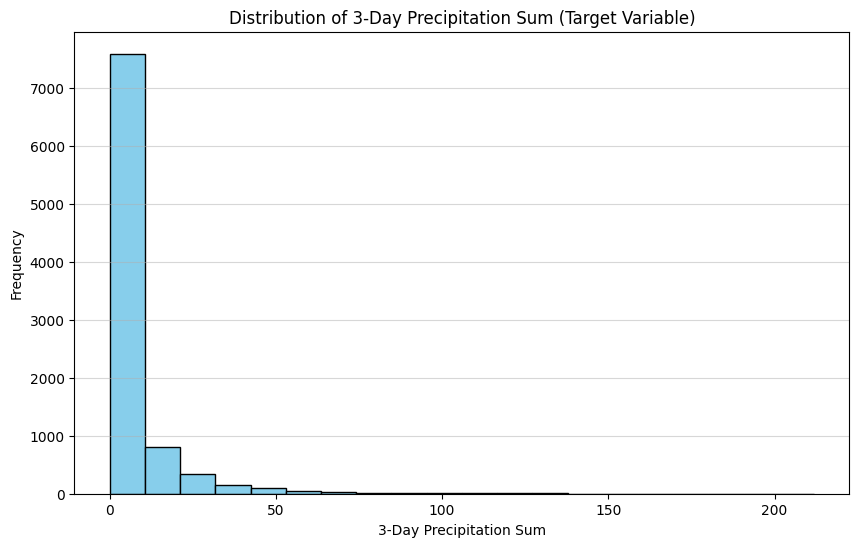

In [23]:
# --- 1. Histogram (Distribution) ---
# Set the 'date' column as the index for plotting
df_cleaned = df_cleaned.set_index('date')
plt.figure(figsize=(10, 6))
# Using hist() from Matplotlib
plt.hist(df_cleaned['target_precip'], bins=20, edgecolor='black', color='skyblue')
plt.title('Distribution of 3-Day Precipitation Sum (Target Variable)')
plt.xlabel('3-Day Precipitation Sum')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.5)
plt.show()

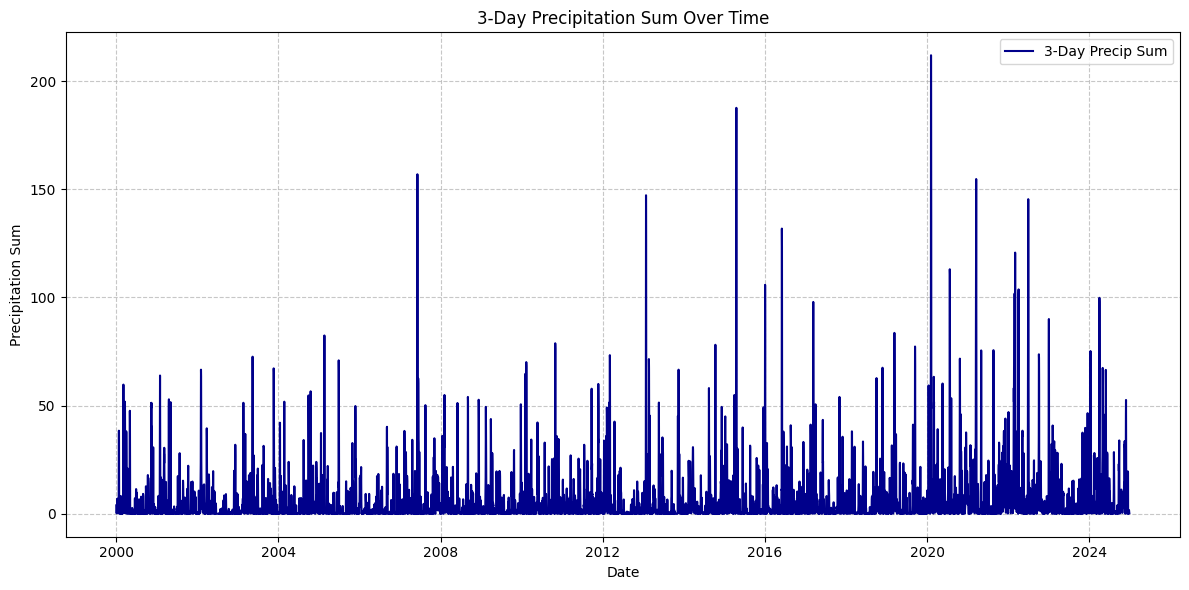

In [24]:
# --- 2. Line Plot (Time Series Trend) ---
plt.figure(figsize=(12, 6))
# Ensure your index is a datetime object for proper plotting
plt.plot(df_cleaned['target_precip'], 
         label='3-Day Precip Sum', color='darkblue')
plt.title('3-Day Precipitation Sum Over Time')
plt.xlabel('Date')
plt.ylabel('Precipitation Sum')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [25]:
# <Student to fill this section>
target_distribution_explanations = """
provide a detailed analysis on the target variable, its distribution, limitations, issues, ...
"""

In [26]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `\<put feature name here\>`

In [27]:
# <Student to fill this section>
numeric_features = [
    'temperature_2m_min', 'precipitation_hours', 'apparent_temperature_min', 
    'wind_gusts_10m_max', 'wind_speed_10m_max', 'wind_direction_10m_dominant',
    'relative_humidity_2m_max', 'dew_point_2m_max', 'cloud_cover_max',
    'surface_pressure_max', 'pressure_msl_max'
]

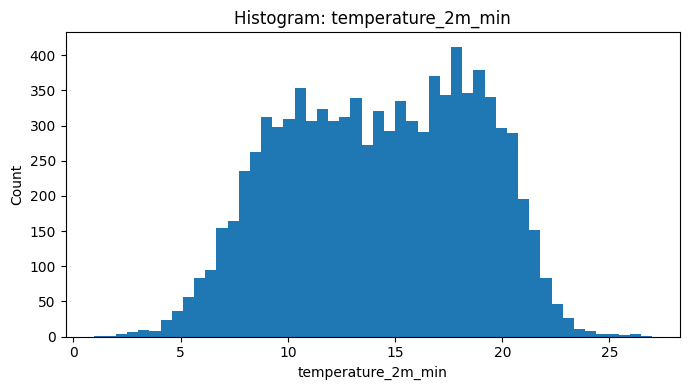

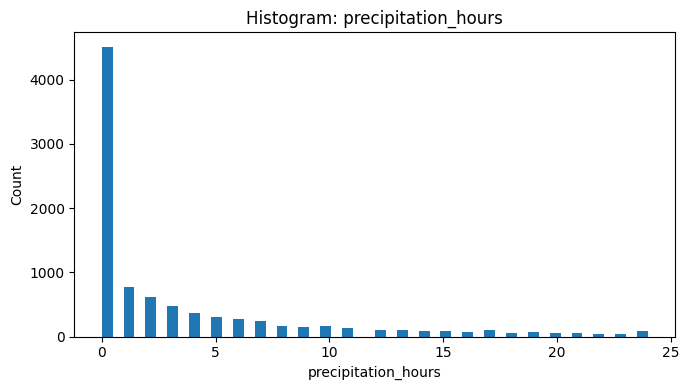

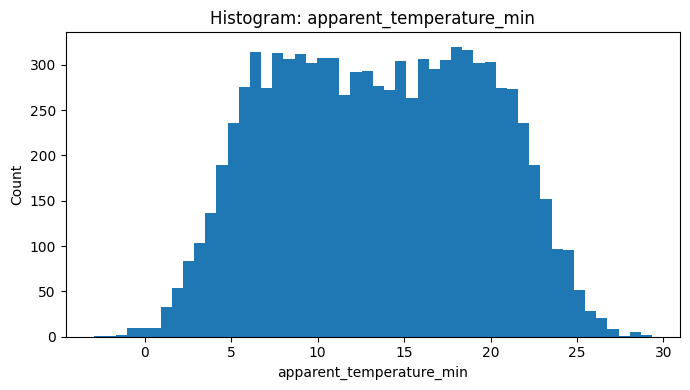

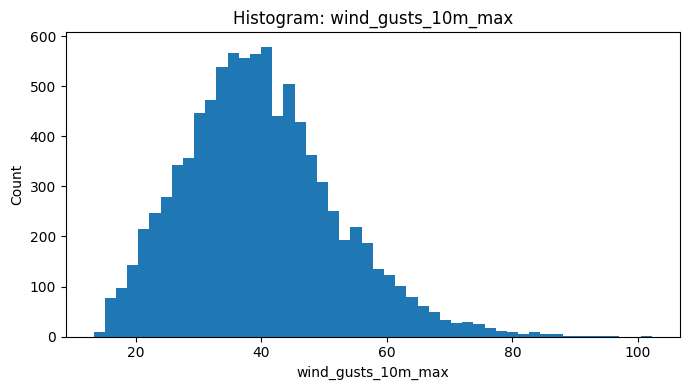

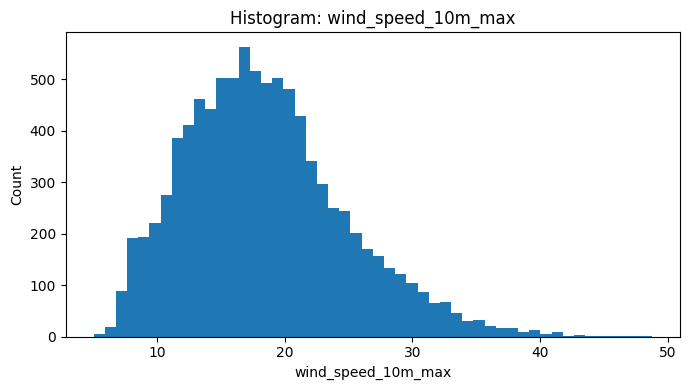

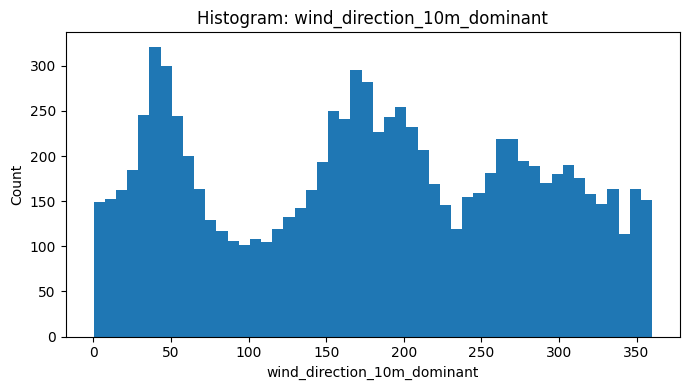

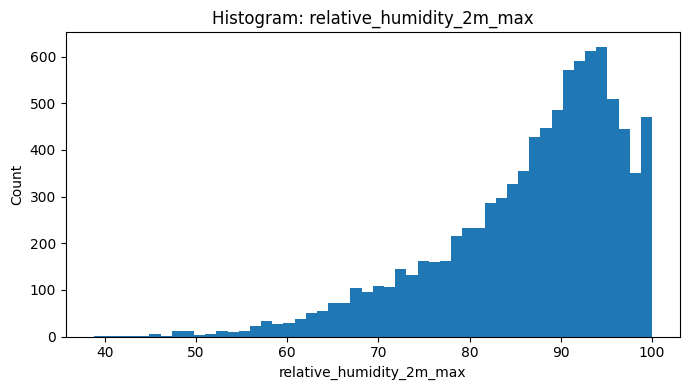

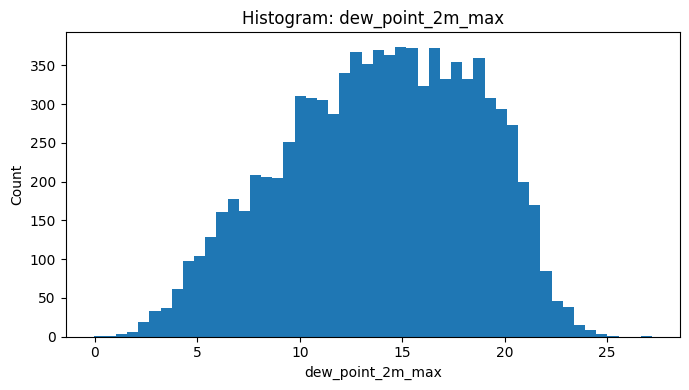

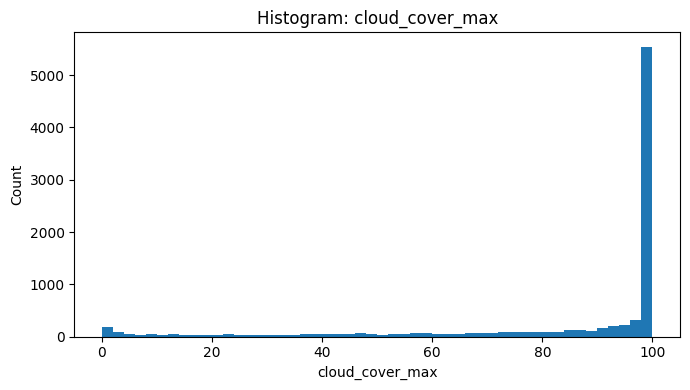

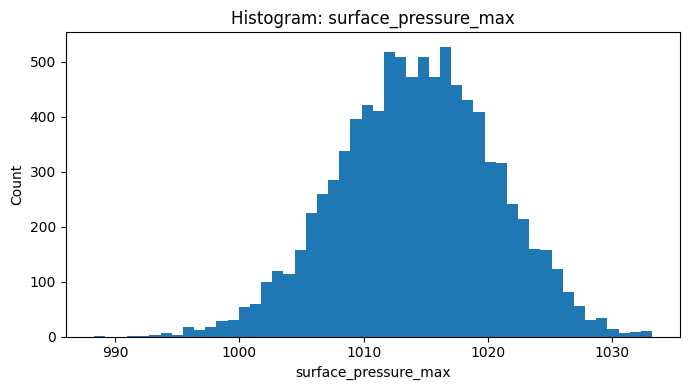

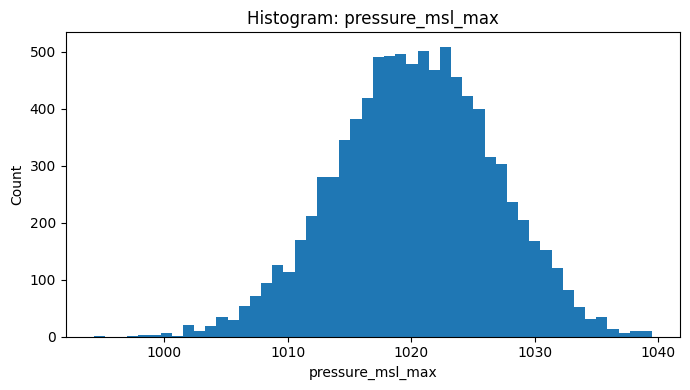

In [28]:
def hist_feature(col, bins=50):
    plt.figure(figsize=(7,4))
    plt.hist(df_cleaned[col].dropna(), bins=bins)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col); plt.ylabel("Count")
    plt.tight_layout(); plt.show()

for col in numeric_features:
    hist_feature(col)

In [116]:
# <Student to fill this section>
feature_1_insights = """
1. dew_point_2m_max (Moisture)

    Analysis: The distribution is symmetrical (Gaussian-like), centered around 15−16∘C. This indicates a well-behaved, continuous feature.

    Value: It's the most direct measure of atmospheric moisture. Higher dew point means more water vapor is available for condensation and rainfall.

    Issue/Action: No major issues; Standard Scaling is highly effective. We created a derived feature, Temperature-Dew Point Spread, which is even more predictive as it measures air saturation.

2. relative_humidity_2m_max (Saturation)

    Analysis: The feature is heavily left-skewed, peaking near 100%, which signifies saturation.

    Value: It measures the air's proximity to saturation. High values are a necessary pre-condition for significant rain.

    Issue/Action: The hard 100% ceiling limits variability. It should be Standard Scaled along with other continuous features.

3. cloud_cover_max (Prerequisite)

    Analysis: It's a U-shaped or bimodal distribution with dominant peaks at 0% (clear) and 100% (overcast).

    Value: It's a direct precursor to precipitation. The 100% peak provides a strong signal for widespread cloudiness, a requirement for heavy rain.

    Issue/Action: Since the extremes dominate, this feature acts almost like a categorical signal ("Is it overcast?"). It will be Standard Scaled as a continuous variable, but its extreme values should be noted.

4. surface_pressure_max / pressure_msl_max (Dynamics)

    Analysis: Both features are symmetrical (Gaussian), centered around 1015−1020 hPa.

    Value: Pressure drives weather systems. Lower pressure (values on the left tail) is associated with rising air and cyclonic activity, highly predictive of precipitation.

    Issue/Action: Ideal features for regression. Standard Scaling is appropriate.

5. wind_direction_10m_dominant (Source of Moisture)

    Analysis: The distribution is cyclical and multi-modal, showing preferred wind directions (e.g., strong peaks around 40∘ and 170∘).

    Value: Indicates the source of the air mass (e.g., from the sea vs. inland), which determines moisture content.

    Issue/Action: Crucially, it must be transformed using Sine/Cosine functions to represent its cyclical nature (360∘=0∘). Treating it as a continuous number is a mathematical error.

6. temperature_2m_min / apparent_temperature_min (Seasonality)

    Analysis: The features are bimodal (two main peaks).  This reflects the clear separation between cold-season and warm-season minimum temperatures.

    Value: Temperature determines the air's maximum moisture capacity. The minimum is relevant for reaching the dew point.

    Issue/Action: The bimodal distribution is a good signal of seasonality. This feature works best when combined with the Day of Year Sine/Cosine features we created.

7. precipitation_hours (Lagged Signal)

    Analysis: The feature is extremely right-skewed, with a massive spike at 0 hours.

    Value: When used as a lagged feature, it is highly predictive, as recent rain duration strongly suggests favorable atmospheric conditions for continued rain.

    Issue/Action: Due to the extreme skewness, it requires a logarithmic transformation (e.g., log(1+precipitation_hours)) before Standard Scaling to prevent the few high values from distorting the feature's influence.
"""

In [117]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `\<put feature name here\>`

In [31]:
# <Student to fill this section>

In [32]:
# <Student to fill this section>
feature_2_insights = """
provide a detailed analysis on the selected feature, its distribution, limitations, issues, ...
"""

In [33]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore Feature of Interest `\<put feature name here\>`


In [34]:
# <Student to fill this section>

In [35]:
# <Student to fill this section>
feature_n_insights = """
provide a detailed analysis on the selected feature, its distribution, limitations, issues, ...
"""

In [36]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

### C.n Explore Feature of Interest `\<put feature name here\>`

> You can add more cells related to other feeatures in this section

---
## D. Feature Selection


### D.1 Approach "\<describe_approach_here\>"


In [37]:
# <Student to fill this section>

In [38]:
# <Student to fill this section>
feature_selection_1_insights = """
provide an explanation on why you use this approach for feature selection and describe its results
"""

In [39]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "\<describe_approach_here\>"


In [40]:
# <Student to fill this section>

In [41]:
# <Student to fill this section>
feature_selection_2_insights = """
provide an explanation on why you use this approach for feature selection and describe its results
"""

In [42]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.n Approach "\<describe_approach_here\>"

> You can add more cells related to other approaches in this section

## D.z Final Selection of Features

In [43]:
# <Student to fill this section>

features_list = [
    'temperature_2m_min',
    'precipitation_hours', 'apparent_temperature_min', 'wind_gusts_10m_max',
    'wind_speed_10m_max', 'wind_direction_10m_dominant',
    'relative_humidity_2m_max', 'dew_point_2m_max', 'cloud_cover_max',
    'surface_pressure_max', 'pressure_msl_max'
]

In [44]:
# <Student to fill this section>
feature_selection_explanations = """
provide a quick explanation on the features selected
"""

In [45]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>

In [46]:
# <Student to fill this section>

In [47]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Provide some explanations on why you believe it is important to fix this issue and its impacts
"""

In [48]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation <put_name_here>

In [49]:
# <Student to fill this section>

In [50]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Provide some explanations on why you believe it is important to fix this issue and its impacts
"""

In [51]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation <put_name_here>

In [52]:
# <Student to fill this section>

In [53]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Provide some explanations on why you believe it is important to fix this issue and its impacts
"""

In [54]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### E.n Fixing "\<describe_issue_here\>"

> You can add more cells related to other issues in this section

---
## F. Feature Engineering

### F.1 New Feature "\<put_name_here\>"


In [55]:
# <Student to fill this section>

In [56]:
# <Student to fill this section>
feature_engineering_1_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [57]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "\<put_name_here\>"




In [58]:
# <Student to fill this section>

In [59]:
# <Student to fill this section>
feature_engineering_2_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [60]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [61]:
# <Student to fill this section>

In [62]:
# <Student to fill this section>
feature_engineering_n_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [63]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.n Fixing "\<describe_issue_here\>"

> You can add more cells related to new features in this section

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [64]:
# <Student to fill this section>

In [65]:
X = df_cleaned[features_list]
y = df_cleaned['target_precip']

print("Shape of X: ", X.shape)
print("\nShape of y: ", y.shape)

Shape of X:  (9129, 11)

Shape of y:  (9129,)


In [66]:
X.columns

Index(['temperature_2m_min', 'precipitation_hours', 'apparent_temperature_min',
       'wind_gusts_10m_max', 'wind_speed_10m_max',
       'wind_direction_10m_dominant', 'relative_humidity_2m_max',
       'dew_point_2m_max', 'cloud_cover_max', 'surface_pressure_max',
       'pressure_msl_max'],
      dtype='object')

In [67]:
# Splitting the dataset
total_samples = X.shape[0]

# Calculate split points (e.g., 70% Train, 15% Validation, 15% Test)
train_size = int(0.70 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

# --- 1. Training Split ---
X_train = X[:train_size]
y_train = y[:train_size]

# --- 2. Validation Split ---
X_val = X[train_size : train_size + val_size]
y_val = y[train_size : train_size + val_size]

# --- 3. Test Split ---
X_test = X[train_size + val_size :]
y_test = y[train_size + val_size :]

print(f"Train samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Train samples: 6390
Validation samples: 1369
Test samples: 1370


In [114]:
# <Student to fill this section>
data_splitting_explanations = """
Splitting the data in this way to retain the time or seasonality in the data features. 70 percent data kept for training while test and validation sets have 15 percent each. No specific splitting function used from sklearn.
"""

In [115]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "\<put_name_here\>"

In [70]:
# <Student to fill this section>

In [71]:
# Scaling the data to bring all the feature data in range
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [110]:
# <Student to fill this section>
data_transformation_1_explanations = """
Scaling the data brings all the features' values in a range which is better for the model training.
"""

In [111]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "\<put_name_here\>"

In [74]:
# <Student to fill this section>

In [75]:
# <Student to fill this section>
data_transformation_2_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [76]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "\<put_name_here\>"

In [77]:
# <Student to fill this section>

In [78]:
# <Student to fill this section>
data_transformation_3_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [79]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [80]:
from pathlib import Path

# Defining the folder to save the csv files
class Args:
    folder_path = Path("../../data/external/AT2_25415629_EXP_5_new")

at = Args()

In [81]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [82]:
# <Student to fill this section>
# Import evaluate_classifier function from my custom package
from ml_eval_viz.sklearn_helpers import evaluate_regressor

In [108]:
# <Student to fill this section>
performance_metrics_explanations = """
Extended my custom package to include regression evaluation. Used RMSE and MAE in combination for evaluating regression problems because they provide complementary views of the model's error distribution, with MAE being less sensitive to outliers while RMSE being more sensitive to outliers.
"""

In [109]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [85]:
# <Student to fill this section>
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

In [106]:
# <Student to fill this section>
algorithm_selection_explanations = """
Handles non-linear interactions among meteorological predictors (temperature, humidity, wind, pressure, cloud cover, prior precipitation, seasonal encodings) without heavy feature engineering.

Robust to outliers and mixed feature scales; minimal preprocessing beyond leakage-safe temporal features.

Ensemble averaging reduces variance, often yielding strong baseline MAE/RMSE on tabular weather data.

Provides feature importance for stakeholder explainability.
"""

In [107]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [88]:
# <Student to fill this section>

In [104]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
No hyperparameters tuned for this baseline experiment. The features itself are not that rich. So, tuning hyperparameters will only result in excessive computation with very less improvement in performance. So, not performing tuning.
"""

In [105]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [91]:
# <Student to fill this section>
model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=5, n_jobs=-1, random_state=42)

### J.4 Model Technical Performance

> Provide some explanations on model performance


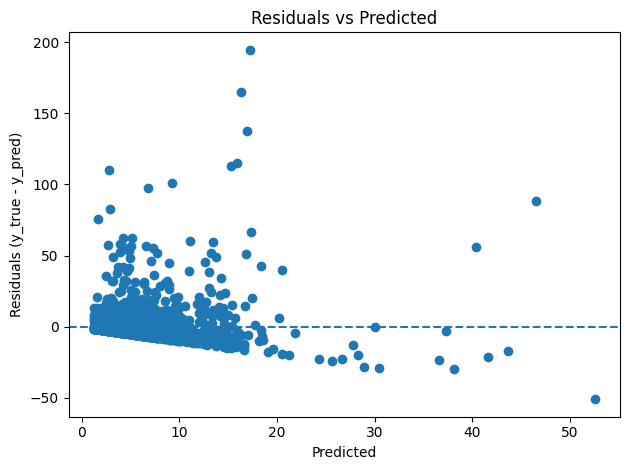

In [92]:
# <Student to fill this section>
report = evaluate_regressor(
    model = model,
    X= X_val_scaled,
    y_true= y_val,
    show_plots = True
)

In [94]:
print(report)

{'mae': 7.405302957813867, 'mse': 238.7443850237007, 'rmse': 15.451355442927998, 'r2': 0.09537833921465422, 'support': 1369}


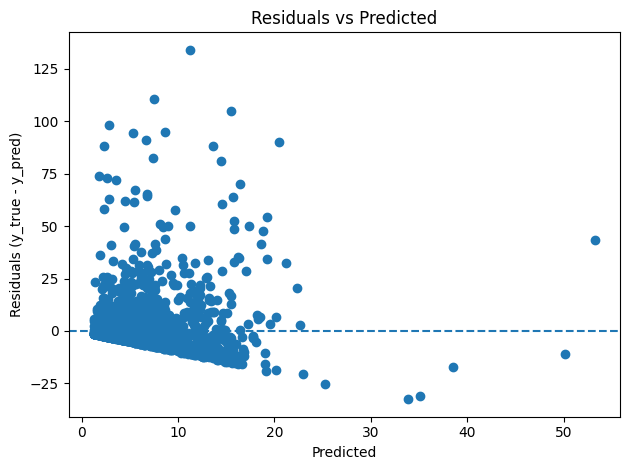

{'mae': 8.15852116179225, 'mse': 235.63122821751648, 'rmse': 15.350284304126633, 'r2': 0.07194517276575496, 'support': 1370}


In [95]:
report = evaluate_regressor(
    model = model,
    X= X_test_scaled,
    y_true= y_test,
    show_plots = True
)

print(report)

In [102]:
# <Student to fill this section>
model_performance_explanations = """
Validation: MAE ≈ 7.4 mm, RMSE ≈ 15.45 mm, R² ≈ 0.095.

Test: MAE ≈ 8.15 mm, RMSE ≈ 15.35 mm, R² ≈ 0.072.

The Random Forest produced stable results across validation and test, with low variance between sets. However, the R² scores are very low (<0.1), indicating the model explains little of the variability in precipitation totals. The errors (MAE ~8 mm) are relatively high compared to the target variable.
"""

In [103]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [ ]:
# <Student to fill this section>

In [100]:
# <Student to fill this section>
business_impacts_explanations = """
Accurate cases: When the model gets close, businesses can anticipate moderate rainfall and adjust operations accordingly.

Inaccurate cases: An 8 mm average error could mean underpredicting heavy rain events (major disruptions in construction, logistics, or events) or overpredicting rain (unnecessary cancellations, costs).

The relatively consistent performance across splits makes it somewhat reliable but not sufficiently precise for high-impact decisions like stormwater management.
"""

In [101]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [98]:
# <Student to fill this section>
experiment_outcome = "Hypothesis rejected" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [99]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [96]:
# <Student to fill this section>
experiment_results_explanations = """
Insight: Random Forest captured non-linearities better than the single tree but still struggled with the complexity and variability of weather.

Reflection: The model may be too shallow (max_depth=5), limiting predictive power. Additional features (lagged variables, atmospheric indices) may be needed.

Next step rationale: Random Forest shows promise as a baseline ensemble, but not production-ready without improvements.
"""

In [97]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)